# Molten Earth Model Simulation

This notebook is for exploring the cooling of an initially molten Earth using the heat-flow model in Chapter 5.5. The section uses a half-space approximation to relate temperature profiles and the near-surface temperature gradient to elapsed cooling time.

**Textbook reference:** Christina Hueschen and Rob Phillips, *The Restless Cell: Continuum Theories of Living Matter* (Princeton University Press, 2024), Chapter 5, §5.5, “The Cooling of the Earth and the Theory of Evolution,” pp. 108–113.

## Derivation following the Fourier-transform calculation for diffusion

We use the same Fourier convention as in the handwritten diffusion derivation:

$$
\widetilde f(k,t)=\int_{-\infty}^{\infty}f(z,t)e^{ikz}\,dz,
\qquad
f(z,t)=\frac{1}{2\pi}\int_{-\infty}^{\infty}\widetilde f(k,t)e^{-ikz}\,dk.
$$

The physical problem is $\partial_tT=D_T\partial_z^2T$ on $z<0$, with $T(z,0)=T_m$ for $z<0$ and $T(0,t)=0$ for $t>0$. First we derive the response to a single initial pulse on the whole line, just as in the diffusion calculation. Then we add those responses to obtain the half-space solution.

**1. Use the same initial pulse, but allow it to start at $s$.**

In the diffusion calculation, $c(x,0)=c_0\delta(x)$ puts the pulse at the origin. Here we define a normalized pulse response $G$ by

$$
\frac{\partial G}{\partial t}=D_T\frac{\partial^2G}{\partial z^2},
\qquad G(z,0;s)=\delta(z-s).
$$

$s$ is the location of the initial pulse. It is a fixed parameter during this calculation. $z$ is the position where we observe the spreading pulse. Taking $s=0$ recovers the initial condition in the handwritten derivation, with unit pulse strength. The notation $G(z,t;s)$ keeps the source position visible.

**2. Fourier transform the heat equation, integrating by parts twice.**

The left side becomes

$$
\int_{-\infty}^{\infty}\frac{\partial G}{\partial t}e^{ikz}\,dz
=\frac{\partial\widetilde G}{\partial t}.
$$

For the right side, the pulse and its spatial derivative vanish at infinity, so both boundary terms vanish:

$$
\begin{aligned}
D_T\int_{-\infty}^{\infty}G_{zz}e^{ikz}\,dz
&=D_T\left[G_ze^{ikz}\right]_{-\infty}^{\infty}
-ikD_T\int_{-\infty}^{\infty}G_ze^{ikz}\,dz\\
&=-ikD_T\left(\left[Ge^{ikz}\right]_{-\infty}^{\infty}
-ik\int_{-\infty}^{\infty}Ge^{ikz}\,dz\right)\\
&=-D_Tk^2\widetilde G.
\end{aligned}
$$

This is exactly the transformed ODE from the diffusion calculation:

$$
\frac{\partial\widetilde G}{\partial t}=-D_Tk^2\widetilde G
\quad\Longrightarrow\quad
\widetilde G(k,t;s)=\widetilde G(k,0;s)e^{-D_Tk^2t}.
$$

**3. The shifted delta function is where $s$ enters the algebra.**

Evaluate the transform of the initial condition:

$$
\widetilde G(k,0;s)=\int_{-\infty}^{\infty}\delta(z-s)e^{ikz}\,dz=e^{iks}.
$$

The delta function picks out the integrand at $z=s$. In the handwritten calculation the pulse was at $s=0$, so this factor was simply 1 (with the pulse strength $c_0$ in front). Now the transform is

$$
\widetilde G(k,t;s)=e^{iks}e^{-D_Tk^2t}.
$$

**4. Invert the transform using the same Gaussian integral.**

$$
\begin{aligned}
G(z,t;s)
&=\frac{1}{2\pi}\int_{-\infty}^{\infty}e^{iks}e^{-D_Tk^2t}e^{-ikz}\,dk\\
&=\frac{1}{2\pi}\int_{-\infty}^{\infty}e^{-D_Ttk^2-ik(z-s)}\,dk.
\end{aligned}
$$

Notice that $e^{iks}e^{-ikz}=e^{-ik(z-s)}$: the shifted initial pulse replaces the $x$ in the original Gaussian integral by $z-s$.

As on the board, complete the square:

$$
-D_Ttk^2-ik(z-s)
=-D_Tt\left(k+\frac{i(z-s)}{2D_Tt}\right)^2
-\frac{(z-s)^2}{4D_Tt}.
$$

Using the Gaussian Fourier integral

$$
\int_{-\infty}^{\infty}e^{-ak^2-ibk}\,dk
=\sqrt{\frac{\pi}{a}}\,e^{-b^2/(4a)},\qquad a>0,
$$

with $a=D_Tt$ and $b=z-s$, we obtain

$$
\boxed{G(z,t;s)=\frac{1}{\sqrt{4\pi D_Tt}}
\exp\!\left[-\frac{(z-s)^2}{4D_Tt}\right].}
$$

This is the same Gaussian as in the diffusion derivation, centered at $s$. It has unit spatial integral. It is also commonly written as $G(z-s,t)$; both notations describe the same kernel. So far $s$ has been one fixed source position, and the only Fourier integration variable was $k$.

**5. Now let $s$ vary to add the contributions from an extended initial temperature profile.**

Earth starts hot everywhere below the surface. Divide that region into slices of width $\Delta s$, centered at positions $s_j<0$. A slice has initial temperature $T_m$ across its width. Approximating that slice by a narrow pulse gives initial profile $T_m\Delta s\,\delta(z-s_j)$ and later contribution $T_m\Delta s\,G(z,t;s_j)$.

Because the heat equation is linear, add those contributions:

$$
T_{\mathrm{hot}}(z,t)\approx\sum_{s_j<0}T_mG(z,t;s_j)\Delta s
\quad\longrightarrow\quad
T_m\int_{-\infty}^{0}G(z,t;s)\,ds.
$$

Here $s$ becomes an integration variable because we are summing over initial source positions. $z$ and $t$ remain fixed while the integral is evaluated. $G$ has units of inverse length, so the factor $ds$ supplies the length needed to give a temperature.

For example, at observation position $z=-20\,\mathrm{m}$, the slice initially at $s=-100\,\mathrm{m}$ contributes a Gaussian weight with separation $80\,\mathrm{m}$. The slice at $s=-200\,\mathrm{m}$ contributes with separation $180\,\mathrm{m}$. Adding every slice gives the temperature at the same observation position.

**6. The second integral is required by the surface boundary condition.**

The single integral above describes an initially hot lower half-line adjoining an initially cold upper half-line, with both free to evolve. At $z=0$, symmetry of the Gaussian gives

$$
T_{\mathrm{hot}}(0,t)=T_m\int_{-\infty}^{0}
\frac{e^{-s^2/(4D_Tt)}}{\sqrt{4\pi D_Tt}}\,ds=\frac{T_m}{2}.
$$

That fails our boundary condition $T(0,t)=0$. To correct it, introduce an imaginary initial temperature $-T_m$ for source positions $s>0$. Its contribution is

$$
T_{\mathrm{mirror}}(z,t)=-T_m\int_{0}^{\infty}G(z,t;s)\,ds.
$$

At the surface this is $-T_m/2$, exactly canceling the first contribution. Equivalently, every real slice at $s<0$ has an equal negative mirror at $-s>0$; each pair cancels at $z=0$ for every $t>0$.

The two integrals in Eq. 5.42 are therefore just the usual diffusion convolution split where an artificial initial profile changes sign:

$$
U_0(s)=\begin{cases}T_m,&s<0,\\-T_m,&s>0,\end{cases}
$$

$$
\begin{aligned}
T(z,t)&=\int_{-\infty}^{\infty}U_0(s)G(z,t;s)\,ds\\
&=T_m\int_{-\infty}^{0}G(z,t;s)\,ds
-T_m\int_{0}^{\infty}G(z,t;s)\,ds,\qquad z<0.
\end{aligned}
$$

We use this construction only below the surface. Its initial temperature there is $T_m$, and its surface temperature is zero. The whole-line Fourier calculation was applied to a localized pulse, for which the integration-by-parts boundary terms vanish; we did not assume the Earth's extended temperature profile vanishes at infinity.

**7. Evaluate the two spatial integrals.**

Set $a=2\sqrt{D_Tt}$ and substitute

$$
u=\frac{z-s}{a},\qquad ds=-a\,du.
$$

For the hot contribution, $s=-\infty$ gives $u=\infty$, and $s=0$ gives $u=z/a$. Reversing the limits to account for the minus sign in $ds$ gives

$$
I_1=\frac{T_m}{\sqrt\pi}\int_{z/a}^{\infty}e^{-u^2}\,du
=\frac{T_m}{2}\left[1-\operatorname{erf}(z/a)\right].
$$

For the mirror contribution, $s=0$ gives $u=z/a$, and $s=\infty$ gives $u=-\infty$. Keep the negative source temperature outside the integral:

$$
I_2=-\frac{T_m}{\sqrt\pi}\int_{-\infty}^{z/a}e^{-u^2}\,du
=-\frac{T_m}{2}\left[1+\operatorname{erf}(z/a)\right].
$$

Here $\operatorname{erf}(v)=(2/\sqrt\pi)\int_0^v e^{-u^2}du$. Adding $I_1$ and $I_2$ cancels the constant halves and gives

$$
\boxed{T(z,t)=-T_m\operatorname{erf}\!\left(\frac{z}{2\sqrt{D_Tt}}\right),\qquad z\leq0,\ t>0.}
$$

At $z=0$, the result is zero. For fixed $z<0$, taking $t\to0^+$ gives $\operatorname{erf}(-\infty)=-1$ and hence the initial temperature $T_m$. Far below the surface at any finite time, it also tends to $T_m$.

The Fourier integral over $k$ constructs the response to one initial pulse. The later spatial integrals over $s$ add those responses over the initial temperature distribution. The negative mirror contribution enforces the fixed surface temperature.

Reference: *The Restless Cell*, §5.5, Eqs. 5.41–5.46, pp. 110–111. Fourier convention follows the supplied handwritten diffusion derivation.


## Initialization and plotting

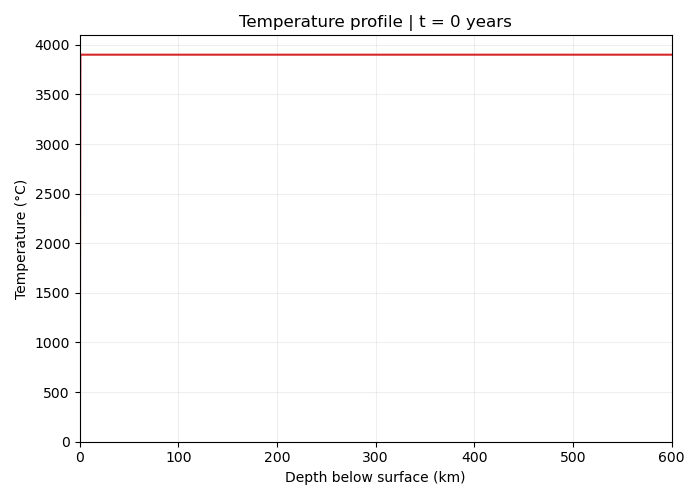

In [16]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
import scipy as scipy

z = np.linspace(-600000, 0, 1000)   # Depth range from -600000 m to 0 m
D_T = 1e-6                          # Thermal diffusivity constant (m^2/s)
T_m = 3900                          # Melting temperature (C)

# Plot depth as a positive distance below the surface, in kilometers.
depth_km = -z / 1000

# Re-running this cell replaces its previous figure.
if "fig" in globals():
    plt.close(fig)
fig, ax_profile = plt.subplots(figsize=(7, 5))
# Initial hot interior and fixed cold surface.
T_initial = np.full_like(z, T_m)
T_initial[z == 0] = 0.0
profile_line, = ax_profile.plot(depth_km, T_initial, color="tab:red")
ax_profile.set(
    xlim=(0, depth_km.max()),
    ylim=(0, T_m * 1.05),
    xlabel="Depth below surface (km)",
    ylabel="Temperature (°C)",
    title="Temperature profile | t = 0 years",
)
ax_profile.set_autoscale_on(False)
time_label = ax_profile.title
ax_profile.grid(alpha=0.2)
fig.tight_layout()
plt.show()


## Time evolution

In [18]:
# Run initialization once to display the widget; run this cell to start or replay.
import time

# Physical cooling time and playback speed are independent.
t_max = abs(z.min())**2 / D_T  # seconds; diffusion time across the plotted depth
seconds_per_year = 365.25 * 24 * 60 * 60
fps = 30
animation_duration = 10  # approximate playback duration in seconds
t_steps = int(fps * animation_duration) + 1
ts = np.linspace(0, t_max, t_steps)

for frame, t in enumerate(ts):
    frame_started = time.perf_counter()
    # The error-function formula applies only for t > 0.
    T = T_initial.copy() if t == 0 else -T_m * scipy.special.erf(
        z / (2 * np.sqrt(D_T * t))
    )
    profile_line.set_ydata(T)
    time_label.set_text(f"Temperature profile | t = {t / seconds_per_year:,.0f} years")
    # Draw immediately, using the same widget refresh as the Vicsek notebook.
    fig.canvas.draw()
    fig.canvas.flush_events()
    # Pace playback, accounting for the time spent calculating and drawing.
    if frame < t_steps - 1:
        time.sleep(max(0, 1 / fps - (time.perf_counter() - frame_started)))


## Observations

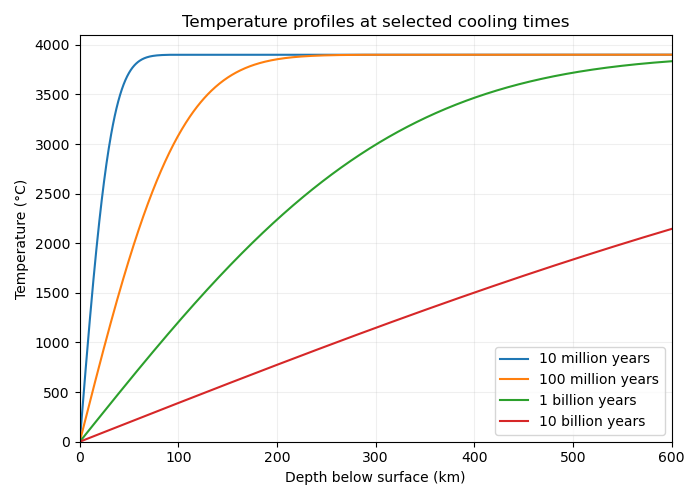

In [19]:
# Compare cooling profiles using the same temperature formula and depth axis.
observation_times = [
    (10_000_000, "10 million years"),
    (100_000_000, "100 million years"),
    (1_000_000_000, "1 billion years"),
    (10_000_000_000, "10 billion years"),
]
seconds_per_year = 365.25 * 24 * 60 * 60

if "fig_observations" in globals():
    plt.close(fig_observations)
fig_observations, ax_observations = plt.subplots(figsize=(7, 5))
for years, label in observation_times:
    t = years * seconds_per_year
    T = -T_m * scipy.special.erf(z / (2 * np.sqrt(D_T * t)))
    ax_observations.plot(depth_km, T, label=label)

ax_observations.set(
    xlim=(0, depth_km.max()),
    ylim=(0, T_m * 1.05),
    xlabel="Depth below surface (km)",
    ylabel="Temperature (°C)",
    title="Temperature profiles at selected cooling times",
)
ax_observations.grid(alpha=0.2)
ax_observations.legend()
fig_observations.tight_layout()
plt.show()
